In [ ]:
from function_lib import *

In [ ]:
# ----------------- config -----------------
n_instance   = 100
input_dim    = 3
noise        = 0.5
deg          = 2
grid_width   = 3
n_simulation = 30
epoch        = 5000
learning_rate = 0.1

# ----------------- paths ------------------
base_path = change_to_py_file_dir()
base      = os.path.join(base_path, "Data", "Shortest_path")

ckpt_root = Path(base_path) / "Result" / "Train" / "ckpt_dir"
log_dir  = Path(base_path) / "Result" / "Train" / "CSVlogger"
ckpt_root.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

# ----------------- graph / solver ---------
G      = define_graph(grid_width)
solver = ShortestPathSolver(G)

# ----------------- results ----------------
total_result  = {}
# =========================================================
# main loop over seeds
# =========================================================
for model_type in ["lst"]:
    regret_result = []
    ModelClass   = get_model_class(model_type)
    for seed in range(n_simulation):
        # ---- reproducibility ----
        pl.seed_everything(seed, workers=True)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        # ---- data ----
        y_train, x_test, y_test, train_dl, valid_dl, test_dl = load_shortest_path_setting_with_splits(base, n_instance, input_dim, deg, noise, grid_width, seed, batch_size=32)

        # optional: pre-compute solpool if you actually use it somewhere
        # otherwise you can safely delete these two lines
        # y_train_t = torch.from_numpy(y_train).float()
        # solpool   = batch_solve(solver, y_train_t, relaxation=False)

        ckpt_dir = ckpt_root / f"{model_type}_seed_{seed}"

        # clean checkpoint directory for this seed
        shutil.rmtree(ckpt_dir, ignore_errors=True)
        ckpt_dir.mkdir(parents=True, exist_ok=True)
        log_dir.mkdir(parents=True, exist_ok=True)

        # ---- network (new net for each seed!) ----
        net = nn.Linear(input_dim, 2 * grid_width * (grid_width - 1))

        # ---- callbacks (recreated each seed) ----
        checkpoint_callback = ModelCheckpoint(
            monitor="val_regret",                 # must match your logged metric name
            dirpath=str(ckpt_dir),
            filename="model-{epoch:02d}-{val_regret:.4f}",
            mode="min",
            save_top_k=1
        )

        early_stop_callback = EarlyStopping(
            monitor="val_regret",
            mode="min",
            patience=100,
            min_delta=0.0,
            verbose=False
        )

        # ---- logger ----
        tb_logger = create_csv_logger(
            log_dir=str(log_dir),
            experiment_name=model_type,
            seed=seed
        )

        # ---- model ----
        sols, edges, G = generate_all_feasible_solutions(grid_width=grid_width)
        tau = 0.1
        loss_flag = 4
        if loss_flag == 1:
            model = LSTModel(listnet_loss, sols, net, solver, tau, lr=1e-1, max_epochs=30)
        elif loss_flag == 2:
            model = LSTModel(dio_loss, sols, net, solver, tau, lr=1e-1, max_epochs=30)
        elif loss_flag == 3:
            model = LSTModel(pairwise_loss, sols, net, solver, tau, lr=1e-1, max_epochs=30)
        elif loss_flag == 4:
            model = LSTModel(likelihood_ranking_loss, sols, net, solver, tau, lr=1e-1, max_epochs=30)

        # ---- trainer ----
        trainer = pl.Trainer(
            max_epochs=epoch,
            min_epochs=5,
            accelerator="auto",            # "auto" is safer; uses GPU if available
            devices=1,
            callbacks=[checkpoint_callback, early_stop_callback],
            logger=tb_logger,
            enable_progress_bar=False,
            deterministic=True
        )

        # optional sanity check: initial validation
        # optional sanity check: initial validation
        trainer.validate(model, dataloaders=valid_dl)

        # ---- training ----
        trainer.fit(model, train_dataloaders=train_dl, val_dataloaders=valid_dl)

        # ---- load best model and test ----
        best_model_path = checkpoint_callback.best_model_path
        if not best_model_path:
            raise RuntimeError(
                f"No checkpoint saved for seed {seed}. "
                "Check that 'val_regret' is logged in validation_step/validation_epoch_end."
            )

        best_model = ModelClass.load_from_checkpoint(
            checkpoint_path=best_model_path,
            net=nn.Linear(input_dim, 2 * grid_width * (grid_width - 1)),  # fresh net with same shape
            solver=solver,
            lr=learning_rate,
            max_epochs=epoch
        )

        test_result = trainer.test(best_model, dataloaders=test_dl)
        regret_result.append(test_result[0]["test_regret"])

    total_result[model_type] = regret_result
    print(f"{model_type} regrets over {n_simulation} seeds:", regret_result)

In [5]:

def compute_stats(arr):
    arr = np.asarray(arr)

    # mean
    mean = np.mean(arr)

    # sample standard deviation (ddof=1)
    std = np.std(arr, ddof=1)

    # VaR 90 (90th percentile)
    var90 = np.percentile(arr, 90)

    # CVaR 90 = mean of tail losses exceeding VaR90
    tail = arr[arr >= var90]
    cvar90 = tail.mean() if len(tail) > 0 else var90

    return mean, std, var90, cvar90

# Example usage:

mean, std, var90, cvar90 = compute_stats(total_result['lst'])

print(f"Mean    : {mean:.6f}")
print(f"Std     : {std:.6f}")
print(f"VaR 90  : {var90:.6f}")
print(f"CVaR 90 : {cvar90:.6f}")

Mean    : 0.106427
Std     : 0.046895
VaR 90  : 0.173669
CVaR 90 : 0.205062


C:\Users\zhaoz\AppData\Local\Temp\ipykernel_24016\576578033.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


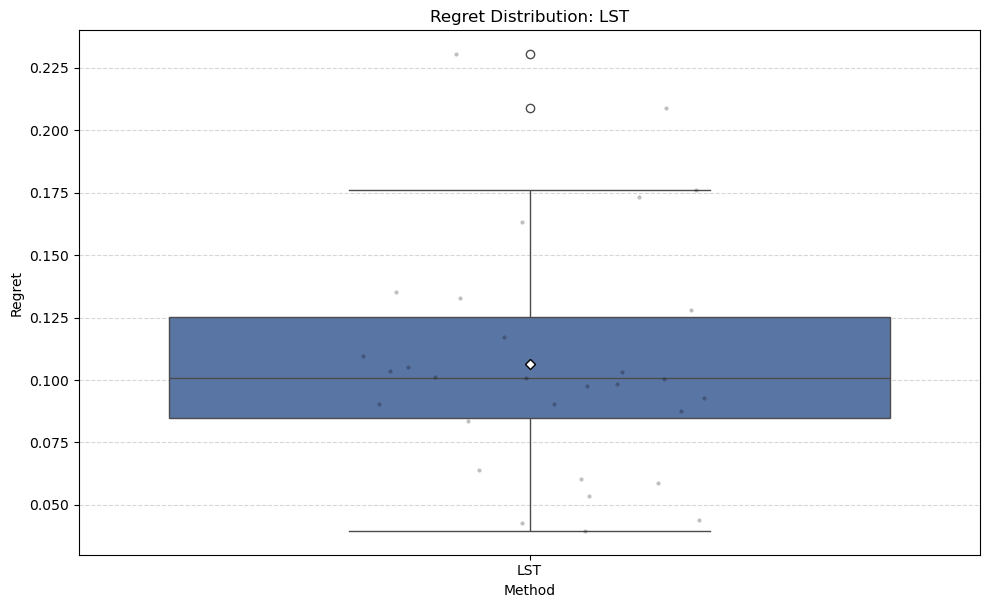

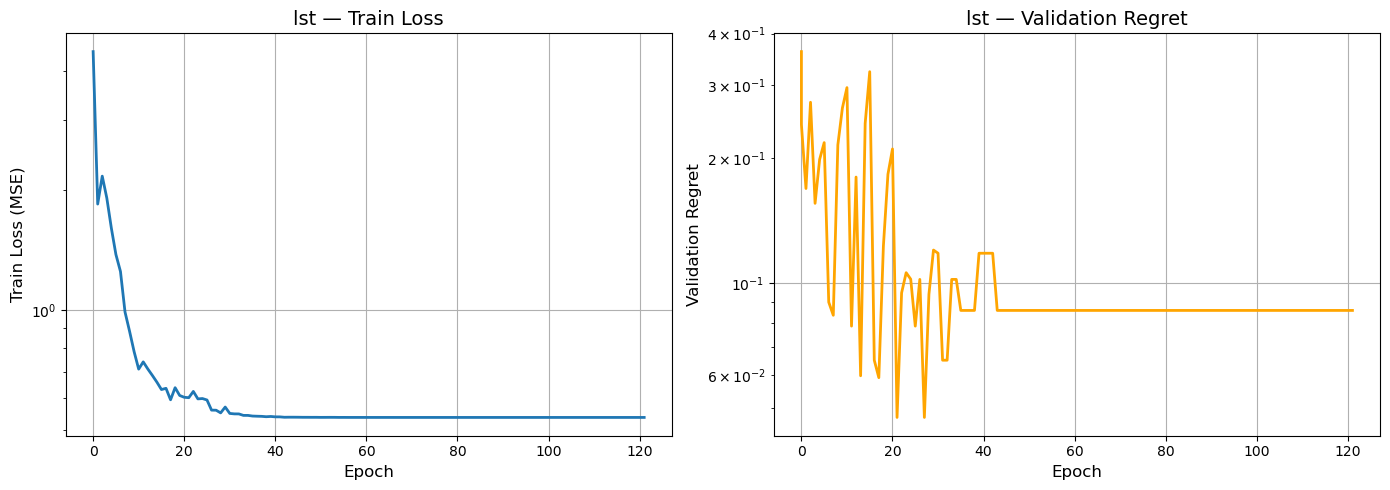

In [6]:
# Prepare data for seaborn
df = pd.DataFrame({
    "regret": total_result["lst"] ,
    "method": ["LST"] * len(total_result["lst"])
})

# Academic color palette
palette = sns.color_palette("deep")  # high-contrast, journal-friendly
method_colors = {"LST": palette[0]}

plt.figure(figsize=figure_size(10))  # Width of 6 inches, height based on golden ratio

sns.boxplot(
    data=df,
    x="method",
    y="regret",
    palette=method_colors,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 5
    }
)

sns.stripplot(
    data=df,
    x="method",
    y="regret",
    color="black",
    alpha=0.25,
    jitter=0.2,
    size=3
)

plt.title("Regret Distribution: LST", fontsize=12)
plt.ylabel("Regret")
plt.xlabel("Method")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(base_path + "\\Result\\Figures\\lst_result_demo.png", dpi=400, bbox_inches='tight')  # Save figure
plt.show()

log_dir = base_path + '/Result/Train/CSVlogger'
plot_training_curves(log_dir, experiment_name=model_type, version=seed)